# Chapter 16 - Machine Learning Asset Allocation

## Preparation

In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import random

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta
import seaborn as sns
from scipy.stats import norm, moment
from scipy.cluster.hierarchy import dendrogram

from utils.data_paths import IVE_TICKS
from utils.sampling_bars import dollar_bar
from utils.hrp import HierarchicalRiskParity
from utils.cla import CriticalLineAlgorithm
from utils.po import PortfolioOptimization

%matplotlib inline
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = 16,6

# df = pd.read_parquet(IVE_TICKS)
# dollar_bars = dollar_bar(df)


In [2]:
def generate_data(num_obs, num_ind_samples, num_corr_samples, sigma1, sigma2):
    np.random.seed(1016)
    random.seed(1016)
    
    # 1. generate some uncorrelated RV
    x = np.random.normal(0, sigma1, size=(num_obs, num_ind_samples))
    
    # 2. generate correlation between random variables
    cols = [random.randint(0, num_ind_samples - 1) for _ in range(num_corr_samples)]
    y = x[:, cols] + np.random.normal(0, sigma2, size=(num_obs, num_corr_samples))
    
    x = np.concatenate([x, y], axis=1)
    x = pd.DataFrame(x, columns=range(1, num_ind_samples + num_corr_samples + 1))
    
    return x, cols

def plot_weights(weights, title):
    ax = sns.barplot(x=weights.columns, y=weights.iloc[0].values)
    ax.set_title(title);
    return ax


def plot_weights_deviation(original_w, new_w, original_name, new_name, title):
    def as_weight_series(weights, index=None, name="weight"):
        if isinstance(weights, pd.DataFrame):
            s = weights.iloc[0]
        elif isinstance(weights, pd.Series):
            s = weights
        else:
            s = pd.Series(np.asarray(weights).ravel(), index=index)

        s = s.astype(float)
        s.name = name
        return s

    original_w_series = as_weight_series(original_w, name=original_name)
    new_w_series = as_weight_series(
        new_w,
        index=original_w_series.index,
        name=new_name
    )

    # Align by asset label, not raw position
    weights_compare = pd.concat([original_w_series, new_w_series], axis=1).loc[original_w_series.index]
    weights_compare["Deviation"] = weights_compare[new_name] - weights_compare[original_name]

    fig, ax = plt.subplots(figsize=(16, 6))

    weights_compare[[original_name, new_name]].plot(
        kind="bar",
        ax=ax,
        width=0.8,
        alpha=0.85
    )

    ax2 = ax.twinx()
    ax2.plot(
        range(len(weights_compare)),
        weights_compare["Deviation"],
        color="black",
        marker="o",
        linewidth=1.5,
        label="Deviation"
    )
    ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")

    ax.set_title(title)
    ax.set_xlabel("Asset")
    ax.set_ylabel("Portfolio Weight")
    ax2.set_ylabel(f"{new_name} - {original_name}")

    lines, labels = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines + lines2, labels + labels2, loc="upper right")

    plt.tight_layout()
    plt.show()

## 1. Given the PnL series on N investment strategies:

### a. Align them to the average frequency of their bets (e.g., weekly observations for strategies that trade on a weekly basis). Hint: This kind of data alignment is sometimes called “downsampling.”

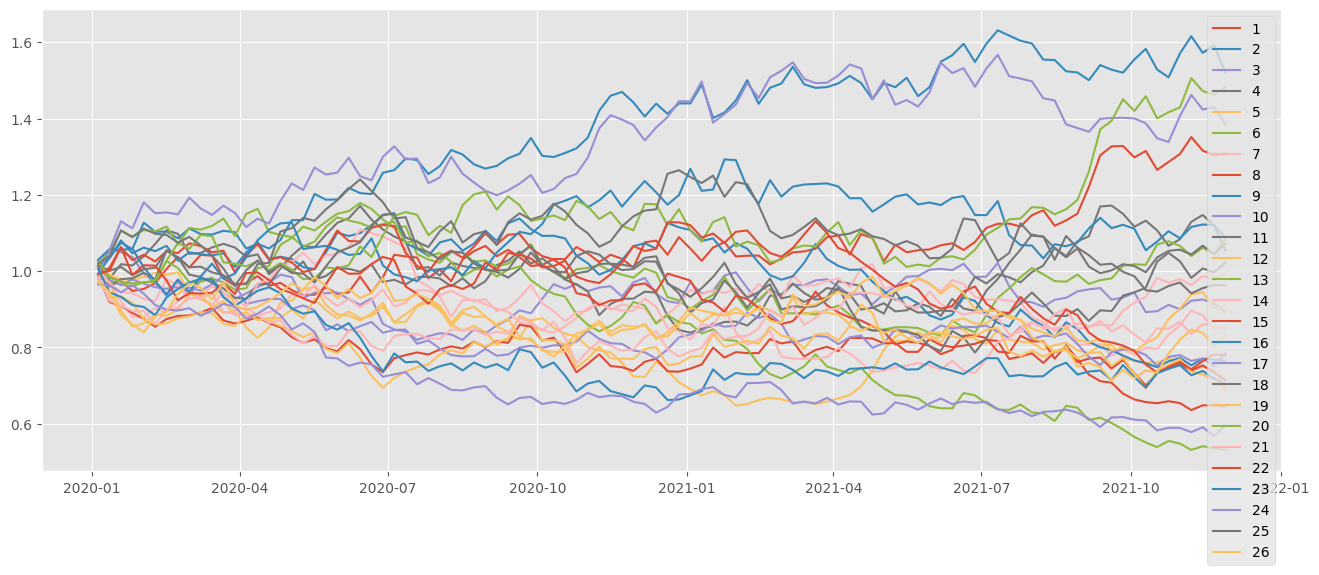

In [3]:
num_obs = 252 * 3 # assume 3 years of data
num_ind_samples = 10
num_corr_samples = 16
sigma1 = 0.01
sigma2 = 0.005

returns_daily, cols = generate_data(num_obs, num_ind_samples, num_corr_samples, sigma1, sigma2)
# reindex x with timestamp
returns_daily.index = pd.date_range(start='2020-01-01', periods=num_obs, freq='D')

x = (1 + returns_daily).cumprod()

# down sample to weekly
x_weekly = x.resample('W').last()

# plot the first 100 observations
plt.plot(x_weekly.iloc[:100])
plt.legend(x_weekly.columns)
plt.show()

In [4]:
hrp = HierarchicalRiskParity()

### b. Compute the covariance of their returns, V.

In [5]:
returns = x_weekly.pct_change().dropna()
V = returns.cov()
corr = returns.corr()

print(V.shape)

(26, 26)


### c. Identify the hierarchical clusters among the N strategies.

In [6]:
clusters = hrp.tree_clustering(corr)

print(f"The shape of the linkage matrix is {clusters.shape}")
clusters

The shape of the linkage matrix is (25, 4)


array([[ 0.        , 19.        ,  0.19502065,  2.        ],
       [ 5.        , 17.        ,  0.19503537,  2.        ],
       [ 7.        , 18.        ,  0.20159859,  2.        ],
       [20.        , 28.        ,  0.20673834,  3.        ],
       [ 6.        , 25.        ,  0.21045761,  2.        ],
       [ 2.        , 15.        ,  0.21351755,  2.        ],
       [22.        , 29.        ,  0.21396554,  4.        ],
       [13.        , 27.        ,  0.21397591,  3.        ],
       [ 8.        , 14.        ,  0.21469381,  2.        ],
       [11.        , 30.        ,  0.2230081 ,  3.        ],
       [10.        , 33.        ,  0.23154643,  4.        ],
       [21.        , 34.        ,  0.23374645,  3.        ],
       [ 9.        , 23.        ,  0.24478824,  2.        ],
       [24.        , 37.        ,  0.24557703,  4.        ],
       [ 1.        , 16.        ,  0.2494198 ,  2.        ],
       [12.        , 39.        ,  0.25660842,  5.        ],
       [26.        , 35.

{'icoord': [[15.0, 15.0, 25.0, 25.0],
  [65.0, 65.0, 75.0, 75.0],
  [55.0, 55.0, 70.0, 70.0],
  [45.0, 45.0, 62.5, 62.5],
  [35.0, 35.0, 53.75, 53.75],
  [85.0, 85.0, 95.0, 95.0],
  [105.0, 105.0, 115.0, 115.0],
  [145.0, 145.0, 155.0, 155.0],
  [135.0, 135.0, 150.0, 150.0],
  [125.0, 125.0, 142.5, 142.5],
  [185.0, 185.0, 195.0, 195.0],
  [175.0, 175.0, 190.0, 190.0],
  [165.0, 165.0, 182.5, 182.5],
  [215.0, 215.0, 225.0, 225.0],
  [245.0, 245.0, 255.0, 255.0],
  [235.0, 235.0, 250.0, 250.0],
  [220.0, 220.0, 242.5, 242.5],
  [205.0, 205.0, 231.25, 231.25],
  [173.75, 173.75, 218.125, 218.125],
  [133.75, 133.75, 195.9375, 195.9375],
  [110.0, 110.0, 164.84375, 164.84375],
  [90.0, 90.0, 137.421875, 137.421875],
  [44.375, 44.375, 113.7109375, 113.7109375],
  [20.0, 20.0, 79.04296875, 79.04296875],
  [5.0, 5.0, 49.521484375, 49.521484375]],
 'dcoord': [[0.0,
   np.float64(0.2494198008078407),
   np.float64(0.2494198008078407),
   0.0],
  [0.0, np.float64(0.21469380747188616), np.floa

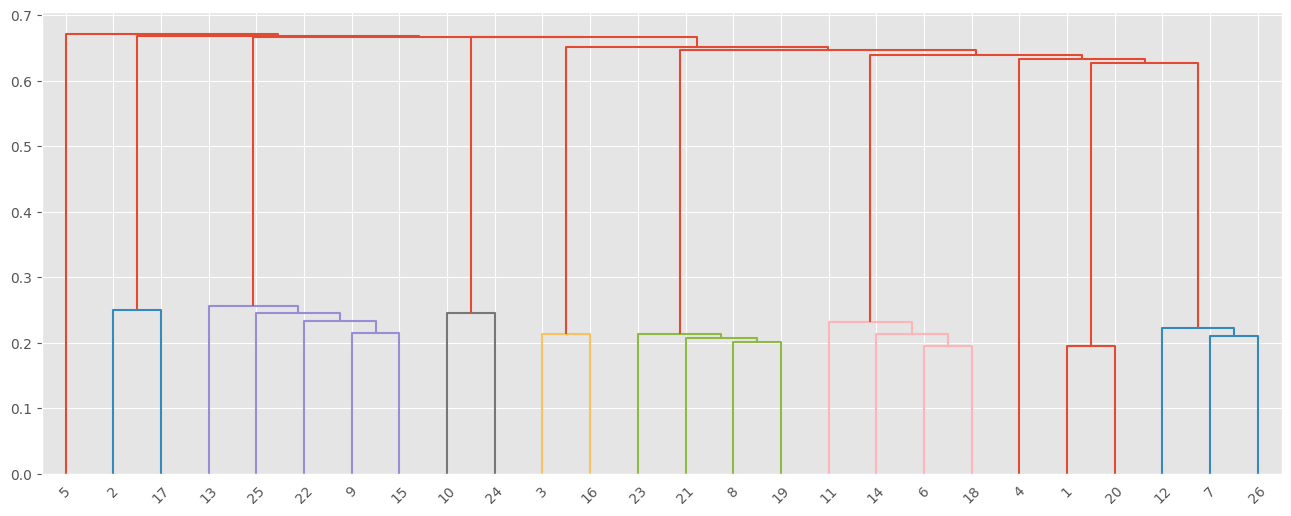

In [7]:
dendrogram(clusters, labels=x_weekly.columns)

### d. Plot the clustered correlation matrix of the N strategies.

In [8]:
quasi_diag = hrp.get_quasi_diag(clusters)

quasi_diag

[4,
 1,
 16,
 12,
 24,
 21,
 8,
 14,
 9,
 23,
 2,
 15,
 22,
 20,
 7,
 18,
 10,
 13,
 5,
 17,
 3,
 0,
 19,
 11,
 6,
 25]

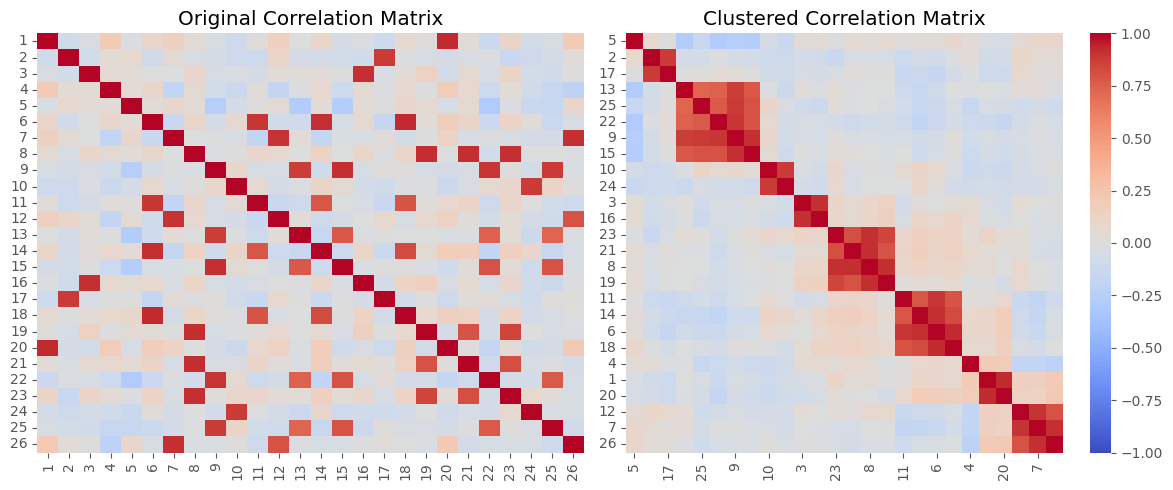

In [9]:
# Plot the original correlation matrix
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.heatmap(corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, cbar=False)
plt.title('Original Correlation Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)

# Plot the clustered correlation matrix
ordered_corr = corr.iloc[quasi_diag, quasi_diag]
plt.subplot(1, 2, 2)
sns.heatmap(ordered_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Clustered Correlation Matrix')
plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

## 2. Using the clustered covariance matrix V from exercise 1:

### a. Compute the HRP allocations.

In [10]:
hrp = HierarchicalRiskParity()

hrp.allocate(x, resample_by="W")

print(hrp.weights)

         5         2         17        13        25        22        9   \
0  0.078033  0.052256  0.037638  0.053416  0.024805  0.025934  0.049263   

         15       10       24  ...        11        14        6         18  \
0  0.039847  0.06294  0.06371  ...  0.035951  0.019956  0.024183  0.048698   

         4         1         20        12        7         26  
0  0.046182  0.052403  0.025888  0.028427  0.019743  0.014412  

[1 rows x 26 columns]


<Axes: title={'center': 'HRP Allocation'}, xlabel='None'>

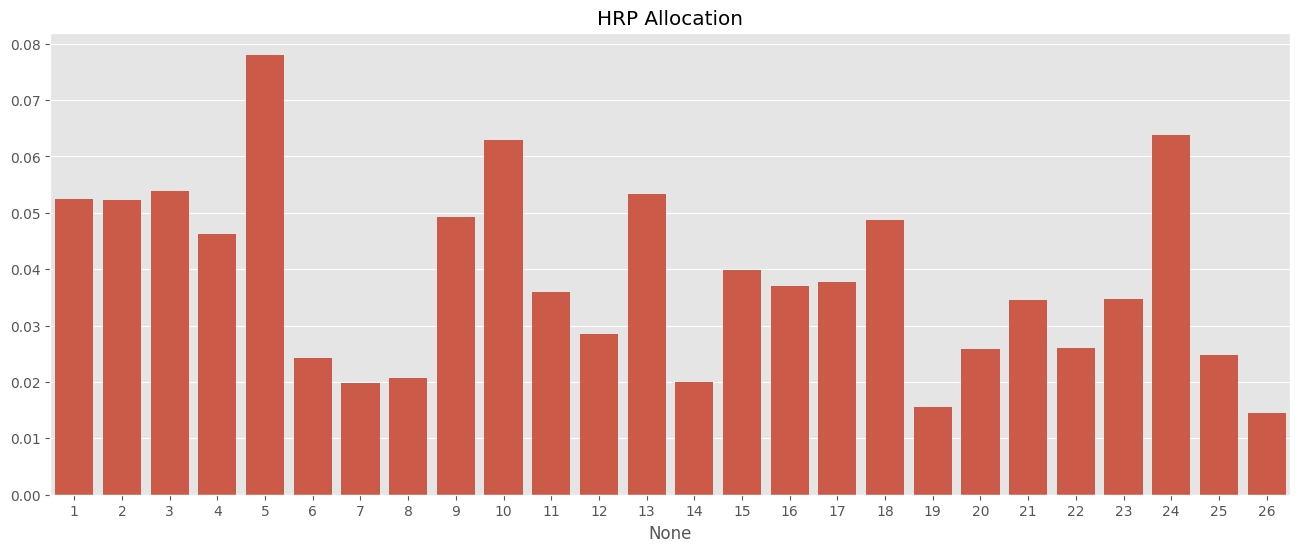

In [11]:
plot_weights(hrp.weights, "HRP Allocation")

### b. Compute the CLA allocations.

In [12]:
cla = CriticalLineAlgorithm()

cla.allocate(asset_prices=x, solution="min_volatility", resample_by="W", covariance=V)

print(cla.weights)

         1         2         3         4        5    6         7    8    9   \
0  0.037589  0.099357  0.068667  0.071147  0.10321  0.0  0.088468  0.0  0.0   

    10  ...       17   18        19        20        21       22   23  \
0  0.0  ...  0.01489  0.0  0.012134  0.038489  0.041191  0.09568  0.0   

         24        25   26  
0  0.157115  0.016452  0.0  

[1 rows x 26 columns]


<Axes: title={'center': 'CLA Allocation'}, xlabel='None'>

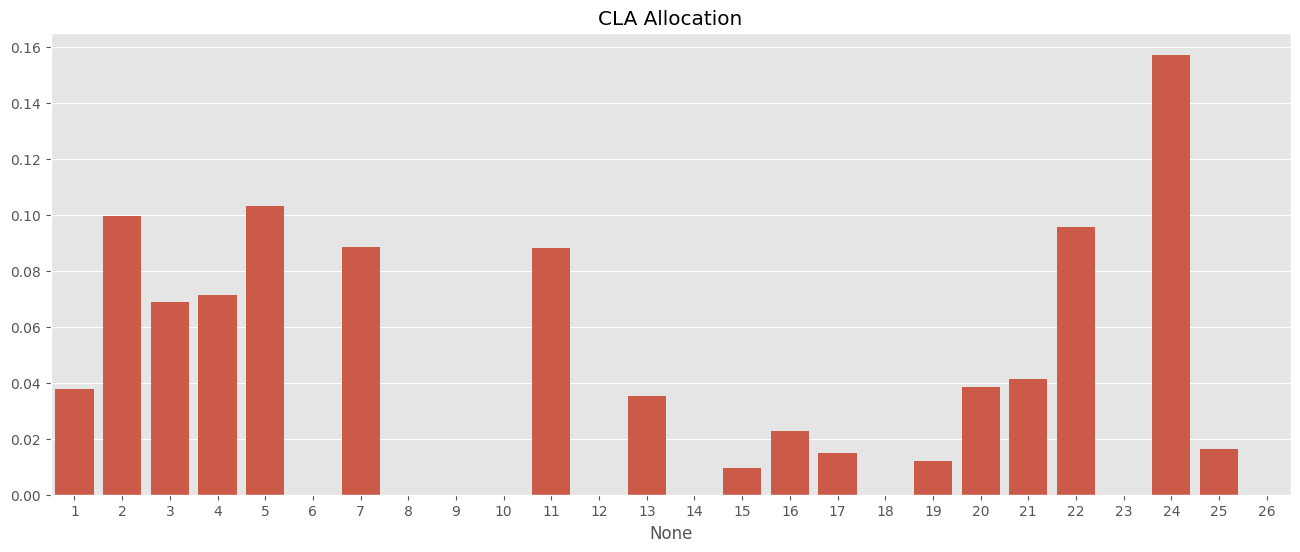

In [13]:
plot_weights(cla.weights, "CLA Allocation")

### c. Compute the IVP allocations.

In [14]:
po = PortfolioOptimization()

po.allocate(asset_prices=x, solution="inverse_variance", resample_by="W")

print(po.weights)

         1         2         3         4         5         6         7   \
0  0.042278  0.048152  0.042198  0.037259  0.038577  0.043018  0.041726   

        8         9         10  ...        17        18        19       20  \
0  0.03801  0.043975  0.059112  ...  0.034683  0.032836  0.028648  0.03286   

         21        22        23        24       25       26  
0  0.033287  0.036645  0.031988  0.049838  0.03505  0.03046  

[1 rows x 26 columns]


<Axes: title={'center': 'IVP Allocation'}, xlabel='None'>

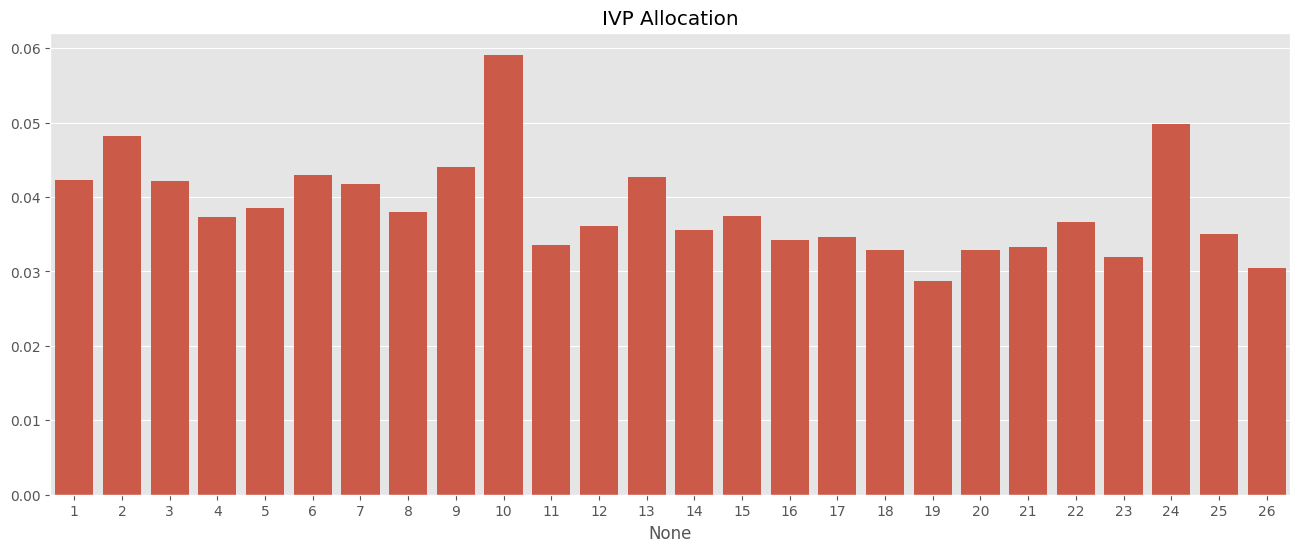

In [15]:
plot_weights(po.weights, "IVP Allocation")

## 3. Using the covariance matrix V from exercise 1:

### a. Perform a spectral decomposition: $VW = W\Lambda$.

In [16]:
# eigen values and eigen vectors
eigen_values, eigen_vectors = np.linalg.eigh(V)

print(np.sort(eigen_values))

[1.45453096e-05 2.14359520e-05 2.57391474e-05 3.62801660e-05
 4.93143742e-05 5.27851827e-05 6.18907684e-05 7.72091063e-05
 1.03606231e-04 1.21423729e-04 1.31970932e-04 1.57015353e-04
 1.67050218e-04 1.96340615e-04 2.09543790e-04 2.33580470e-04
 6.60741647e-04 7.11860706e-04 9.90160778e-04 1.43876272e-03
 1.58058939e-03 1.59894357e-03 2.43736150e-03 2.92889732e-03
 3.38254986e-03 3.90778376e-03]


In [17]:
# SVD
u, s, v = np.linalg.svd(V)

print(np.sort(s))

[1.45453096e-05 2.14359520e-05 2.57391474e-05 3.62801660e-05
 4.93143742e-05 5.27851827e-05 6.18907684e-05 7.72091063e-05
 1.03606231e-04 1.21423729e-04 1.31970932e-04 1.57015353e-04
 1.67050218e-04 1.96340615e-04 2.09543790e-04 2.33580470e-04
 6.60741647e-04 7.11860706e-04 9.90160778e-04 1.43876272e-03
 1.58058939e-03 1.59894357e-03 2.43736150e-03 2.92889732e-03
 3.38254986e-03 3.90778376e-03]


In [18]:
# spectral decomposition
W = eigen_vectors
Lambda = np.diag(eigen_values)

### b. Form an array $\epsilon$ by drawing $N$ random numbers from a $U[0, 1]$  distribution.

In [19]:
n = V.shape[0]
epsilon = np.random.uniform(0, 1, size=n)

epsilon.shape

(26,)

### c. Form an NxN matrix $\tilde{\Lambda}_{n,n}$, where $\tilde{\Lambda}_{n,n} = \frac{N\epsilon_{n}\Lambda_{n,n}}{(\sum_{n=1}^{N}\epsilon_{n})} $, n = 1, ..., N.

In [20]:
normalized_epsilon = epsilon / np.sum(epsilon)
Lambda_tilde = np.diag(normalized_epsilon * eigen_values * n)

### d. Compute $\tilde{V} = W\tilde{\Lambda}W^{-1}$

In [21]:
V_tilde = W @ Lambda_tilde @ W.T

### e. Repeat exercise 2, this time using as covariance matrix. What allocation method has been most impacted by the re-scaling of spectral variances?

#### HRP

In [22]:
d_matrix = np.zeros_like(V_tilde)
diagnoal_sqrt = np.sqrt(np.diag(V_tilde))
np.fill_diagonal(d_matrix, diagnoal_sqrt)
d_inv = np.linalg.inv(d_matrix)
corr_tilde = d_inv.T @ V_tilde @ d_inv
corr_tilde = pd.DataFrame(corr_tilde, index=x_weekly.columns, columns=x_weekly.columns)

V_tilde_df = pd.DataFrame(V_tilde, index=x_weekly.columns, columns=x_weekly.columns)

new_hrp = HierarchicalRiskParity()

# we have to perform step by step instead calling `allocate()`

clusters_tilde = hrp.tree_clustering(corr_tilde)
ordered_indices_tilde = hrp.get_quasi_diag(clusters_tilde)
hrp_weights_tilde = hrp.recursive_bisection(x_weekly, V_tilde_df, ordered_indices_tilde)

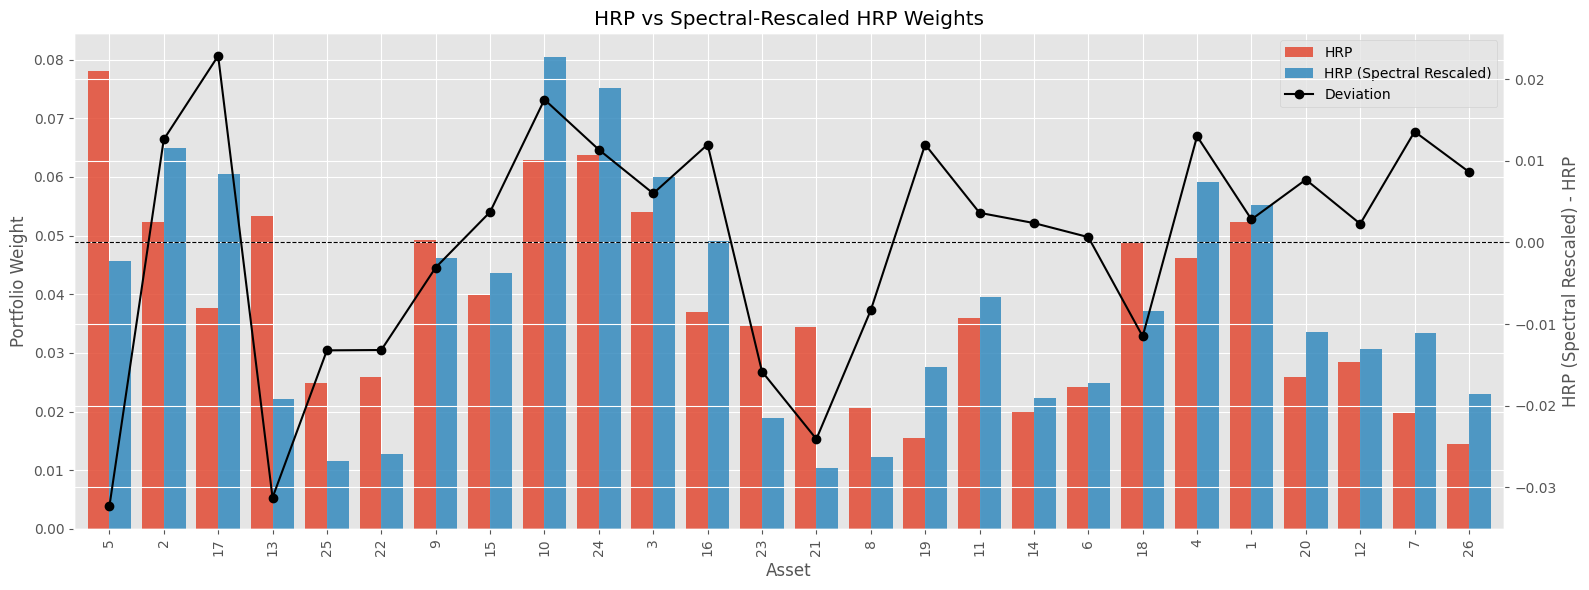

In [23]:
plot_weights_deviation(hrp.weights, hrp_weights_tilde, "HRP", "HRP (Spectral Rescaled)", "HRP vs Spectral-Rescaled HRP Weights")

#### CLA

In [24]:
new_cla = CriticalLineAlgorithm()

new_cla.allocate(x, solution="min_volatility", resample_by="W", covariance=V_tilde_df)


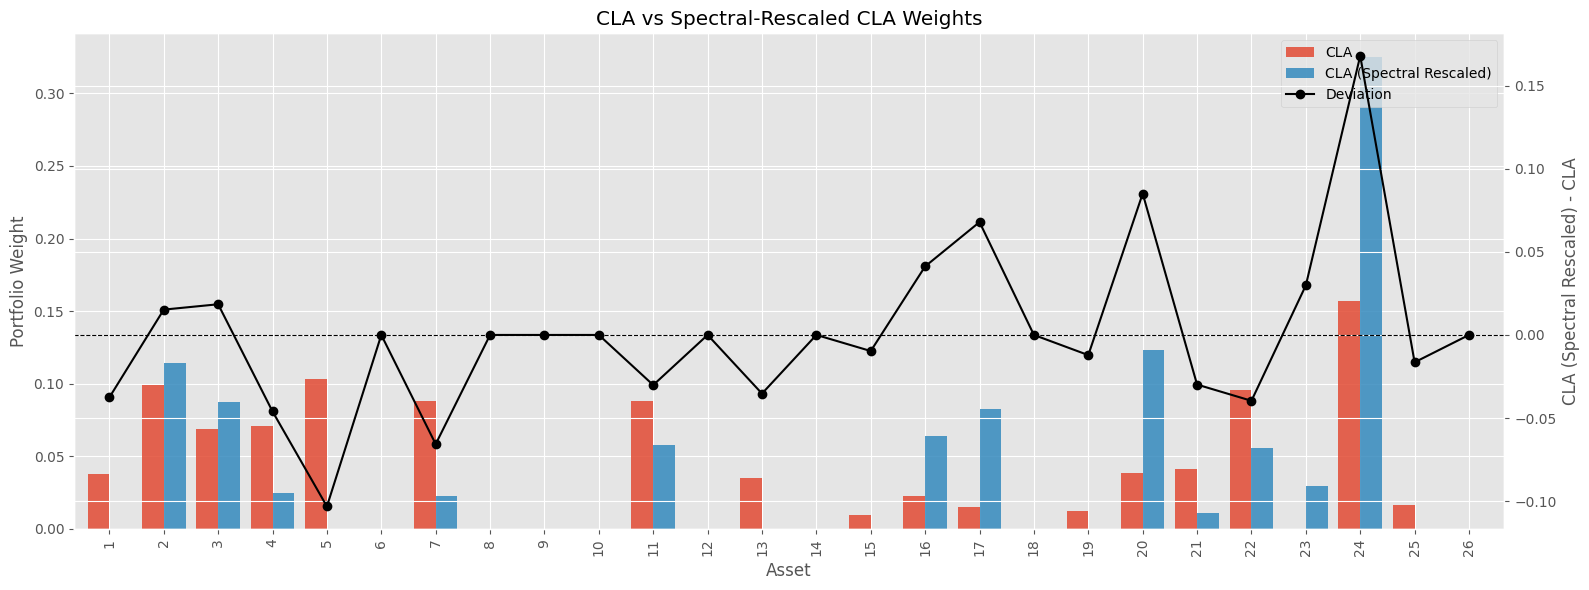

In [25]:
plot_weights_deviation(cla.weights, new_cla.weights, "CLA", "CLA (Spectral Rescaled)", "CLA vs Spectral-Rescaled CLA Weights")

#### IVP

In [26]:
new_po = PortfolioOptimization()

new_po.allocate(x, solution="inverse_variance", resample_by="W", covariance=V_tilde_df)

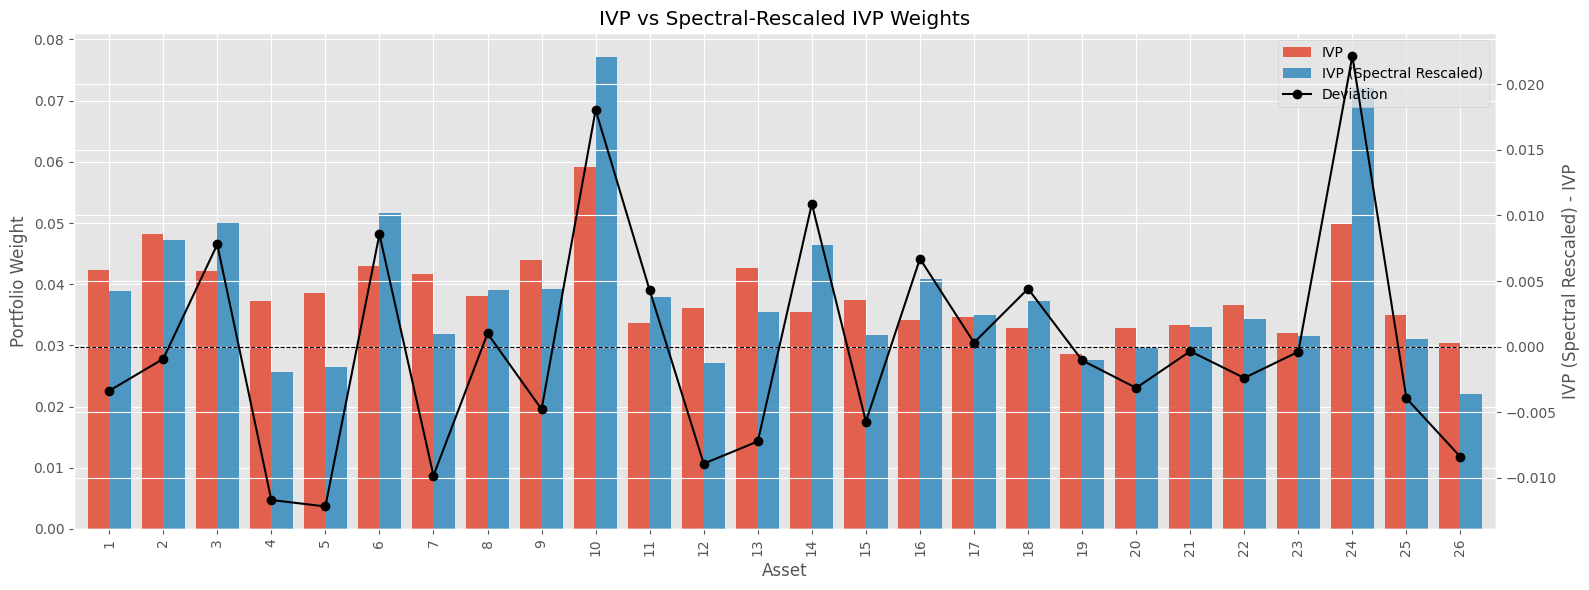

In [27]:
plot_weights_deviation(po.weights, new_po.weights, "IVP", "IVP (Spectral Rescaled)", "IVP vs Spectral-Rescaled IVP Weights")

CLA and HRP are impacted by a very similar amount, with CLA slightly larger by L1 deviation in this run. IVP is less impacted.

## 4. How would you modify the HRP algorithm to produce allocations that add  up to 0, where $|w_n| \leq 1$, $\forall n = 1, \dots, N$?

We can use HRP for risk-budget magnitudes. Assume we have a machine learning model/strategy that produce long-short signal as 1 and -1. Then we normalize long weights to +1 and short weights to -1 so net exposure is zero.

If all the signals are long signals, we can either convert the scores into relative signals by demeaning or ranking, and then short the low-ranked asset (say 25% percentile), or we can short a benchmark/ETF/futures hedge.

## 5. Can you think of an easy way to incorporate expected returns in the HRP allocations?

We can simply scale the HRP weights by the expected returns, and then re-normalize the weights. It is intuitive that the higher the expected returns, the more weights of that asset.

In other words, let $w_h \in \mathbb{R}^N$ be the HRP weight with $N$ asset, $\mu \in \mathbb{R}^N$ be the expected returns, $\tilde{w}$ be the new weights, and * be the element-wie multiplication:

$$\tilde{w} = w_h * \mu$$
$$\tilde{w} = \frac{\tilde{w}}{\sum_i \tilde{w_i}}$$

Or we can have the following code:

```python
hrp_w = hrp_weights
mu = expected_returns

tilt = mu.clip(lower=0)
w = hrp_w * tilt
w = w / w.sum()
```